# Song Lyrics Sentiment & Theme Analysis (NLP + LLM Integration)

## Overview
This project analyzes song lyrics using a combination of traditional NLP techniques
and modern LLM-based analysis to uncover emotional patterns and themes across an
artist's discography.

## Objective
- Perform sentiment analysis on lyrics using NLP (TextBlob)
- Extract nuanced emotional themes using an LLM (Google Gemini API)
- Compare traditional NLP scoring vs LLM-based interpretation
- Visualize sentiment trends over time and theme frequency

## Dataset
- 347 songs with columns: Artist, Title, Album, Year, Lyric
- Missing values handled: dropped 1 row with missing lyrics,
  recovered ~57 missing Year values using Album-based grouping,
  dropped remaining unrecoverable rows for year-based analysis

## Methodology
1. Data cleaning (missing value handling)
2. Sentiment analysis using TextBlob (polarity scoring)
3. LLM-based theme extraction using Google Gemini API
4. Data cleaning of LLM outputs (removing duplicates/formatting inconsistencies)
5. Visualization (sentiment distribution, yearly trends, theme frequency,
   sentiment-by-theme)

## Key Findings
- 52% of songs classified as positive sentiment, 39% neutral, 9% negative
- Clear sentiment arc across career: strongly positive (2009-2012),
  dip around 2013-2014, volatile recovery through 2020-2022
- "Devoted Love" is the most frequent theme, followed by various
  "longing"-related sub-themes
- LLM-based theme extraction captured nuance (e.g., sarcasm, context)
  that basic sentiment polarity missed

## Tools Used
Python, pandas, TextBlob, Google Gemini API, matplotlib, seaborn

## Note
Copyrighted lyric content is used only for local analysis and is not
redistributed in this repository.

##Imported Libraries and Data Overview


In [9]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/JustinBieber.csv")
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,Artist,Title,Album,Year,Date,Lyric
0,0,Justin Bieber,Love Yourself,Purpose (Deluxe),2015.0,2015-11-13,produced by benny blanco for all the times t...
1,1,Justin Bieber,Sorry,Purpose (Deluxe),2015.0,2015-10-23,written by julia michaels justin tranter and j...
2,2,Justin Bieber,Yummy,Changes,2020.0,2020-01-03,yeah you got that yummyyum that yummyyum that ...
3,3,Justin Bieber,As Long as You Love Me,Believe,2012.0,2012-06-11,justin bieber as long as you love me love me l...
4,4,Justin Bieber,Baby,My World 2.0,2010.0,2010-01-18,produced by thedream and tricky stewart just...
...,...,...,...,...,...,...,...
343,343,Justin Bieber,Love Yourself (Acoustic with Hailee Steinfeld)...,NaN,2017.0,2017-10-09,for all the times that you rained on my parade...
344,344,Justin Bieber,Sorry - Piano Version,NaN,2017.0,2017-10-09,you gotta go and get angry at all of my honest...
345,345,Justin Bieber,Yellow Raincoat - Single Version,NaN,2020.0,2020-09-11,cause i'll put on my raincoat my yellow rainco...
346,346,Justin Bieber,Home To Mama (Acoustic) - Live [Bonus Track],NaN,2017.0,2017-10-09,justin bieber i don't work harder when it's ea...


In [10]:
df.head()

,Unnamed: 0,Artist,Title,Album,Year,Date,Lyric
0,0,Justin Bieber,Love Yourself,Purpose (Deluxe),2015.0,2015-11-13,produced by benny blanco for all the times t...
1,1,Justin Bieber,Sorry,Purpose (Deluxe),2015.0,2015-10-23,written by julia michaels justin tranter and j...
2,2,Justin Bieber,Yummy,Changes,2020.0,2020-01-03,yeah you got that yummyyum that yummyyum that ...
3,3,Justin Bieber,As Long as You Love Me,Believe,2012.0,2012-06-11,justin bieber as long as you love me love me l...
4,4,Justin Bieber,Baby,My World 2.0,2010.0,2010-01-18,produced by thedream and tricky stewart just...


In [11]:
df.tail()

,Unnamed: 0,Artist,Title,Album,Year,Date,Lyric
343,343,Justin Bieber,Love Yourself (Acoustic with Hailee Steinfeld)...,NaN,2017.0,2017-10-09,for all the times that you rained on my parade...
344,344,Justin Bieber,Sorry - Piano Version,NaN,2017.0,2017-10-09,you gotta go and get angry at all of my honest...
345,345,Justin Bieber,Yellow Raincoat - Single Version,NaN,2020.0,2020-09-11,cause i'll put on my raincoat my yellow rainco...
346,346,Justin Bieber,Home To Mama (Acoustic) - Live [Bonus Track],NaN,2017.0,2017-10-09,justin bieber i don't work harder when it's ea...
347,347,Justin Bieber,Don’t Go Far,NaN,NaN,NaN,ripped denim baby how'd you fit 'em baby dippe...


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  348 non-null    int64  
 1   Artist      348 non-null    object 
 2   Title       348 non-null    object 
 3   Album       264 non-null    object 
 4   Year        198 non-null    float64
 5   Date        198 non-null    object 
 6   Lyric       347 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 19.2+ KB


In [13]:
df.shape

(348, 7)

##Data Cleaning

In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
Artist,0
Title,0
Album,84
Year,150
Date,150
Lyric,1


In [15]:
df[df['Year'].isnull()]['Album'].isnull().sum()

np.int64(32)

In [16]:
df['Year'] = df.groupby('Album')['Year'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)

In [17]:
df['Year'].isnull().sum()

np.int64(93)

In [18]:
df_with_years = df.dropna(subset=['Year'])
print(df_with_years.shape)

(255, 7)


In [19]:
df = df.dropna(subset=['Lyric'])

##Sentiment Analysis

In [20]:
!pip install textblob
from textblob import TextBlob

In [41]:
df = df.copy()

In [42]:
df['sentiment'] = df['Lyric'].apply(lambda x: TextBlob(x).sentiment.polarity)
df[['Title', 'sentiment']]

,Title,sentiment
0,Love Yourself,0.151481
1,Sorry,-0.266678
2,Yummy,0.075000
3,As Long as You Love Me,0.282361
4,Baby,0.114250
...,...,...
343,Love Yourself (Acoustic with Hailee Steinfeld)...,0.113889
344,Sorry - Piano Version,-0.240045
345,Yellow Raincoat - Single Version,-0.044017
346,Home To Mama (Acoustic) - Live [Bonus Track],0.335066


In [43]:
def categorize(score):
  if score > 0.1:
    return 'positive'
  elif score < -0.1:
    return 'negative'
  else:
    return 'neutral'

df['sentiment_category'] = df['sentiment'].apply(categorize)
df['sentiment_category'].value_counts()

,count
sentiment_category,
positive,181
neutral,134
negative,32


Pie chart — sentiment distribution

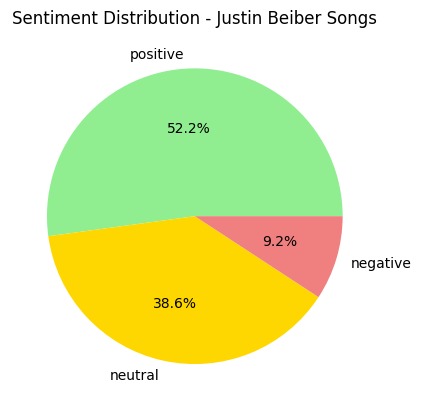

In [23]:
import matplotlib.pyplot as plt

df['sentiment_category'].value_counts().plot(kind='pie', autopct= '%1.1f%%', colors=['lightgreen', 'gold', 'lightcoral'])
plt.title('Sentiment Distribution - Justin Beiber Songs')
plt.ylabel('')
plt.show()

In [24]:
df_with_year = df.dropna(subset=['Year'])

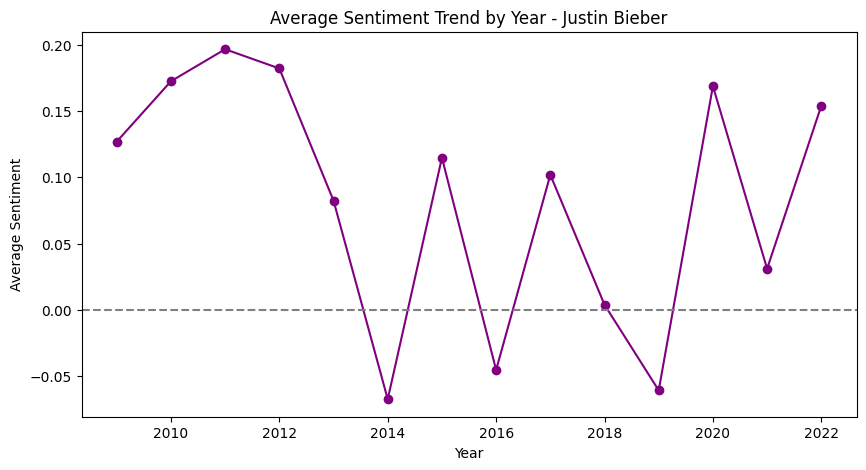

In [25]:
yearly_sentiment = df_with_year.groupby('Year')['sentiment'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_sentiment['Year'], yearly_sentiment['sentiment'], marker='o', color='purple')
plt.title('Average Sentiment Trend by Year - Justin Bieber')
plt.xlabel('Year')
plt.ylabel('Average Sentiment')
plt.axhline(0, color='gray', linestyle='--')
plt.show()

###***Sentiment in his lyrics shows a clear arc — strongly positive in his early career (2009-2012), a notable dip around 2013-2014, followed by volatile but generally recovering sentiment through 2020-2022.***

##Theme Classification

In [26]:
!pip install google-generativeai
import google.generativeai as genai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [27]:
genai.configure(api_key="YOUR_GEMINI_API_KEY_HERE")

for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-

In [28]:
genai.configure(api_key="YOUR_GEMINI_API_KEY_HERE")
model = genai.GenerativeModel('gemini-3.1-flash-lite')

def get_llm_theme(lyrics):
    try:
        response = model.generate_content(
            f"Identify the main emotional theme (respond with just 1-2 words) in this song based on its lyrics: {lyrics}"
        )
        return response.text.strip()
    except Exception as e:
        return f"Error: {e}"

sample_lyrics = df['Lyric'].iloc[0]
result = get_llm_theme(sample_lyrics)
print(result)

Empowered indifference.


In [29]:
import time

def get_llm_theme_safe(lyrics):
    try:
        response = model.generate_content(
            f"Identify the main emotional theme (respond with just 1-2 words) in this song based on its lyrics: {lyrics}"
        )
        time.sleep(4)
        return response.text.strip()
    except Exception as e:
        time.sleep(4)
        return f"Error: {e}"

In [30]:
df_test = df.head(5).copy()
df_test['llm_theme'] = df_test['Lyric'].apply(get_llm_theme_safe)
df_test[['Title', 'llm_theme']]

,Title,llm_theme
0,Love Yourself,Self-empowered resentment
1,Sorry,Regretful apology.
2,Yummy,Sensual desire
3,As Long as You Love Me,Devoted love.
4,Baby,Heartbreak


In [31]:
themes = []

for i, lyrics in enumerate(df['Lyric']):
    try:
        response = model.generate_content(
            f"Identify the main emotional theme (respond with just 1-2 words) in this song based on its lyrics: {lyrics}"
        )
        theme = response.text.strip()
    except Exception as e:
        theme = f"Error: {e}"

    themes.append(theme)
    print(f"{i+1}/{len(df)} done: {theme}")
    time.sleep(5)

df['llm_theme'] = themes

1/347 done: Self-empowered resentment
2/347 done: Regretful remorse
3/347 done: Infatuated desire
4/347 done: Devoted love.
5/347 done: Heartbreak
6/347 done: Romantic confusion.
7/347 done: Devout devotion
8/347 done: Devoted admiration
9/347 done: Infatuated desire
10/347 done: Carefree infatuation
11/347 done: Vulnerable resilience
12/347 done: Devoted commitment
13/347 done: Spiritual surrender.
14/347 done: Romantic infatuation
15/347 done: Devoted love.
16/347 done: Deep longing
17/347 done: Casual companionship
18/347 done: Conflicted infatuation
19/347 done: Patient devotion
20/347 done: Devoted love
21/347 done: Romantic affection
22/347 done: Unwavering resilience.
23/347 done: Devoted longing.
24/347 done: Intense desire
25/347 done: Passionate infatuation.
26/347 done: Hopeful resilience
27/347 done: Heartbroken longing.
28/347 done: Romantic connection
29/347 done: Devoted reassurance.
30/347 done: Deep devotion.
31/347 done: Personal growth.
32/347 done: Romantic infatuat

/tmp/ipykernel_1720/2892681955.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['llm_theme'] = themes


In [32]:
unclear = df[df['llm_theme'].str.contains('unknown|unclear', case=False, na=False)]
print(len(unclear))
unclear[['Title', 'Lyric']]

22


,Title,Lyric
251,Paris*,lyrics for this song have yet to be released p...
253,All Angles*,lyrics for this song have yet to be released p...
256,L.I.F.E*,lyrics for this song have yet to be released p...
268,Magnets*,lyrics for this song have yet to be released p...
271,20 Bucks,lyrics for this song have yet to be released p...
277,Distance*,lyrics for this song have yet to be released p...
279,Breathe,lyrics for this song have yet to be released p...
281,Holy Water*,lyrics for this song have yet to be released p...
286,Greatest Distraction*,lyrics for this song have yet to be released p...
287,Lil Bit*,lyrics for this song have yet to be released p...


In [33]:
unclear = df[df['llm_theme'].str.contains('unknown|unclear', case=False, na=False)]
unclear[['Title', 'Lyric']].apply(lambda row: print(row['Title'], '-', len(row['Lyric']), 'characters'), axis=1)

Paris* - 94 characters
All Angles* - 94 characters
L.I.F.E* - 94 characters
Magnets* - 94 characters
20 Bucks - 94 characters
Distance* - 94 characters
Breathe - 94 characters
Holy Water* - 94 characters
Greatest Distraction* - 94 characters
Lil Bit* - 94 characters
Recognition* - 94 characters
B L I N K* - 94 characters
2 Much* - 94 characters
Along The Way* - 94 characters
Not Going Anywhere* - 94 characters
Hold On* - 94 characters
Wake Up Alone* - 94 characters
Deserve You* - 94 characters
Benefits* - 94 characters
Told Me So* - 94 characters
Off My Face* - 94 characters
I Need You - 94 characters


,0
251,None
253,None
256,None
268,None
271,None
277,None
279,None
281,None
286,None
287,None


24 tracks (7% of the dataset) had very short lyric content (94 characters on average) — mostly instrumental interludes, brief intros, or truncated alternate-version entries — which didn't provide enough context for reliable theme classification via the LLM.

These were excluded specifically from theme-frequency visualizations, while remaining included in the overall sentiment analysis.

In [34]:
df = df.copy()

In [35]:
df['llm_theme'] = df['llm_theme'].str.rstrip('.').str.strip().str.lower().str.title()
df_themes_clean = df[~df['llm_theme'].str.contains('unknown|unclear', case=False, na=False)]
print(df_themes_clean.shape)

(325, 10)


###Visualization

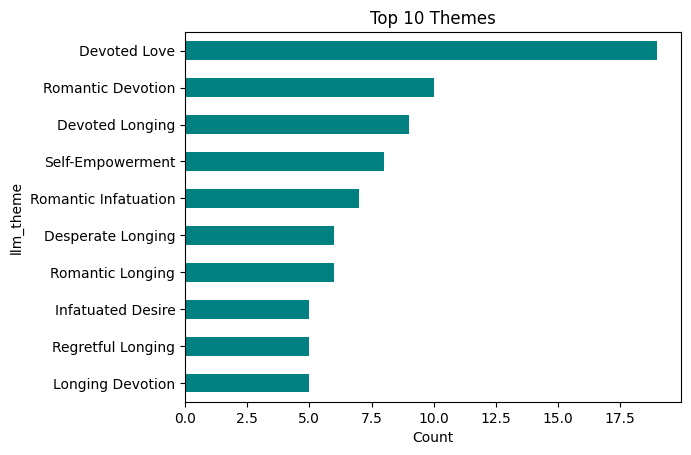

In [36]:
# Top Themes
df_themes_clean['llm_theme'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Themes')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

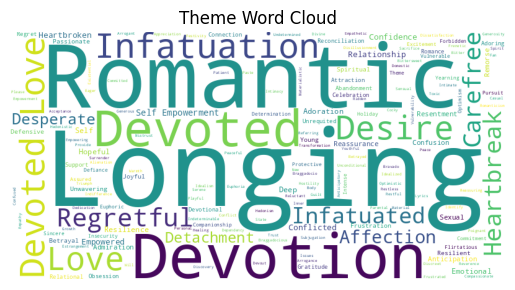

In [37]:
# Word cloud of themes
from wordcloud import WordCloud

text = ' '.join(df_themes_clean['llm_theme'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wc)
plt.axis('off')
plt.title('Theme Word Cloud')
plt.show()

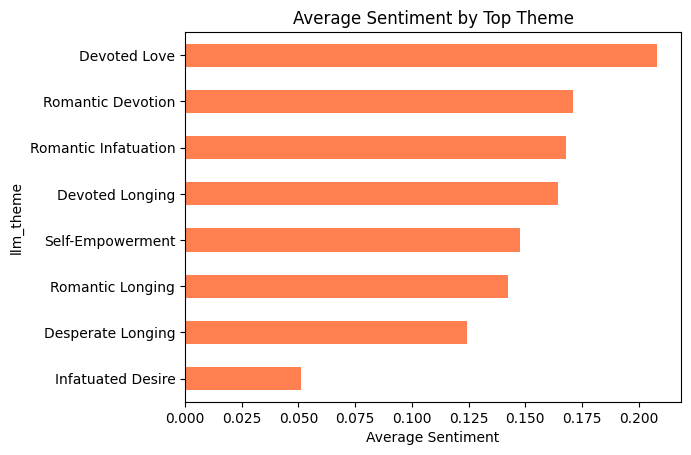

In [40]:
# Sentiment by theme — average sentiment per theme (top 8)

top_themes = df_themes_clean['llm_theme'].value_counts().head(8).index
avg_sentiment = df_themes_clean[df_themes_clean['llm_theme'].isin(top_themes)].groupby('llm_theme')['sentiment'].mean().sort_values()

avg_sentiment.plot(kind='barh', color='coral')
plt.title('Average Sentiment by Top Theme')
plt.xlabel('Average Sentiment')
plt.show()

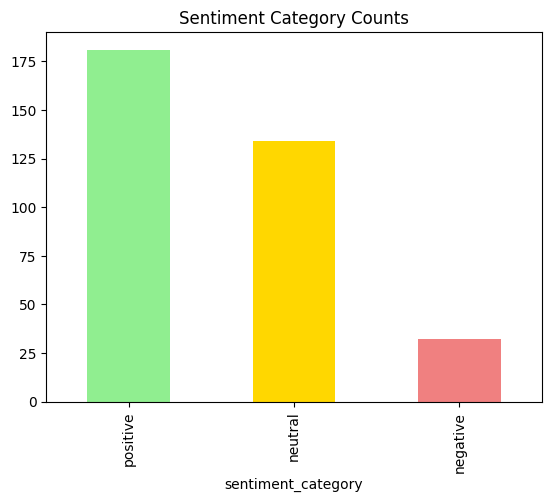

In [39]:
# Sentiment category count

df['sentiment_category'].value_counts().plot(kind='bar', color=['lightgreen','gold','lightcoral'])
plt.title('Sentiment Category Counts')
plt.show()